In [6]:
import random
import gymnasium as gym
import numpy as np
import collections
from tqdm import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, terminated):
        self.buffer.append((state, action, reward, next_state, terminated))

    def sample(self, batch_size):
        transitions = random.sample(self.buffer, batch_size)

        # *transitions unpacks the list of tuples into separate args for zip. zip then groups by field: (s,a,r), (s,a,r), ... → (s,s,...), (a,a,...), (r,r,...)
        state, action, reward, next_state, terminated = zip(*transitions)
        # np.array(state) converts a tuple of arrays into a 2D array. torch.tensor() can only handle a single 2D numpy array but not a tuple of 1D numpy arrays
        return np.array(state), action, reward, np.array(next_state), terminated

    def size(self):
        return len(self.buffer)

In [3]:
class Qnet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
class DQN:
    def __init__(self, state_dim, hidden_dim, action_dim, learning_rate, gamma, epsilon, target_update, device):
        self.action_dim = action_dim
        self.q_net = Qnet(state_dim, hidden_dim, self.action_dim).to(device)
        self.target_q_net = Qnet(state_dim, hidden_dim, self.action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=learning_rate)

        self.gamma = gamma  # discount factor
        self.epsilon = epsilon
        self.target_update = target_update  # target Qnet update frequency
        self.count = 0
        self.device = device

    def take_action(self, state):
        if np.random.random() < self.epsilon:
            action = np.random.randint(0, self.action_dim)
        else:
            state = torch.tensor(state).to(self.device)
            action = self.q_net(state).argmax().item()
        return action

    def update(self, transition_dict):
        # torch.float is an alias for torch.float32
        # states has a shape (batch_size, state_dim)
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        # view(-1, 1) turns the 1D tensor into 2D tensor with the second dimension of size 1
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        terminated = torch.tensor(transition_dict['terminated'], dtype=torch.float).view(-1, 1).to(self.device)

        q_values = self.q_net(states).gather(1, actions)  # (batch_size, 1)
        # .max(dim) is a pytorch function that calculates the maximum value along the dimension dim and returns a tuple consisting of the maximum values and their corresponding indices
        max_next_q_values = self.target_q_net(next_states).max(1)[0].view(-1, 1)
        q_targets = rewards + self.gamma * max_next_q_values * (1 - terminated)

        dqn_loss = F.mse_loss(q_values, q_targets, reduction='mean')
        self.optimizer.zero_grad()
        dqn_loss.backward()
        self.optimizer.step()

        if self.count % self.target_update == 0:
            self.target_q_net.load_state_dict(self.q_net.state_dict())
        self.count += 1


In [7]:
lr = 2e-3
num_episodes = 500
hidden_dim = 128
gamma = 0.98
epsilon = 0.01
target_update = 10
buffer_size = 10000
minimal_size = 500
batch_size = 64
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

env = gym.make('CartPole-v1')
random.seed(0)
np.random.seed(0)
env.reset(seed=0)  # Just for seeding
torch.manual_seed(0)  # Network weight initialization is random

replay_buffer = ReplayBuffer(buffer_size)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon, target_update, device)

return_list = []
# We split the 500 episodes into 10 chunks just for progress reporting so tqdm can show a progress bar per chunk
for i in range(10):
    with tqdm(total=num_episodes // 10, desc='Iteration %d' % i) as pbar:
        for i_episode in range(num_episodes // 10):
            episode_return = 0
            state, info = env.reset()
            done = False
            while True:
                action = agent.take_action(state)
                next_state, reward, terminated, truncated, info = env.step(action)
                replay_buffer.add(state, action, reward, next_state, terminated)
                state = next_state
                episode_return += reward

                if replay_buffer.size() > minimal_size:
                    b_s, b_a, b_r, b_ns, b_t = replay_buffer.sample(batch_size)
                    transition_dict = {
                        'states': b_s,
                        'actions': b_a,
                        'rewards': b_r,
                        'next_states': b_ns,
                        'terminated': b_t
                    }
                    agent.update(transition_dict)

                if terminated or truncated:
                    break

            return_list.append(episode_return)
            if (i_episode + 1) % 10 == 0:
                pbar.set_postfix({
                    'episode': '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return': '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)

Iteration 9: 100%|██████████| 50/50 [00:40<00:00,  1.22it/s, episode=500, return=322.700]


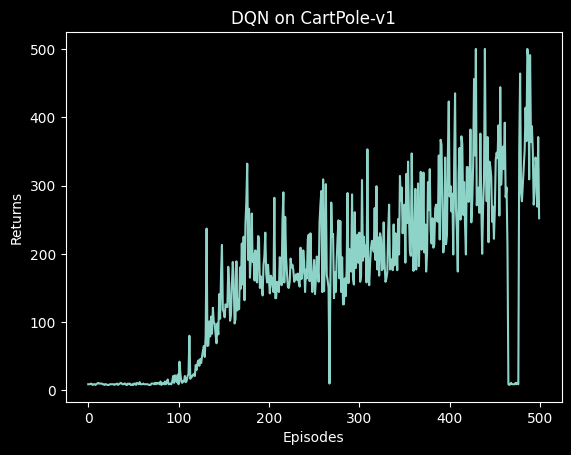

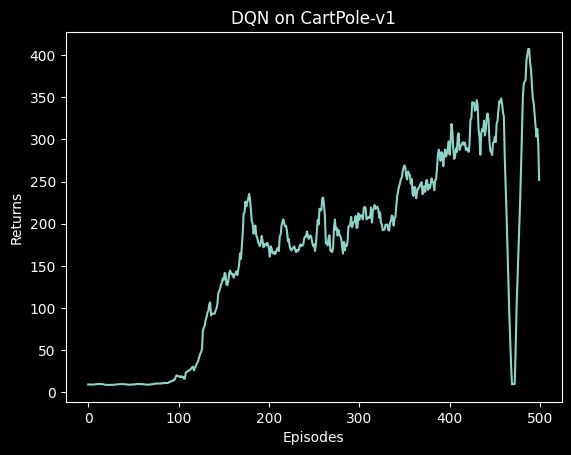

In [9]:
def moving_average(a, window_size):
    # np.insert() inserts at index 0 the value 0; cumsum calculates the prefix sum
    cumulative_sum = np.cumsum(np.insert(a, 0, 0))
    # each element in middle corresponds to the average of sum(a[i:i+window_size]) = cumsum[i+window_size] - cumsum[i]
    middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size

    r = np.arange(1, window_size-1, 2)
    # begin calculates the average of the first 1, 3, ... elements, which we assign to the 1st, 2nd, etc. element in the array a as the moving average with a smaller window_size
    begin = np.cumsum(a[:window_size-1])[::2] / r
    end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
    return np.concatenate((begin, middle, end))

episode_list = list(range(len(return_list)))
plt.plot(episode_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on CartPole-v1')
plt.show()

mv_return = moving_average(return_list, 9)
plt.plot(episode_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on CartPole-v1')
plt.show()
